### Affichage polaire hrosailing

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Compat NumPy 2.x pour libs anciennes
if not hasattr(np, "float_"):
    np.float_ = np.float64

import hrosailing.pipeline as pipe
import hrosailing.processing as proc
import hrosailing.core.modelfunctions as mod

pol_pips = [
    pipe.PolarPipeline(
        data_handler=proc.ArrayHandler(),
        imputator=proc.FillLocalImputator(),
        extension=pipe.TableExtension(neighbourhood=proc.Cuboid(dimensions=(5,300)))
    ),
    pipe.PolarPipeline(
        data_handler=proc.ArrayHandler(),
        imputator=proc.RemoveOnlyImputator(),
        extension=pipe.PointcloudExtension(interpolator=proc.ImprovedIDWInterpolator())
    ),
    pipe.PolarPipeline(
        data_handler=proc.ArrayHandler(),
        imputator=proc.RemoveOnlyImputator(),
        extension=pipe.CurveExtension(regressor=proc.LeastSquareRegressor(model_func=mod.ws_concave_dt_wa))
    )
]

df = pd.read_parquet("../Cleaned_Data/Cleaned_RDR2018 Sortie Manche.parquet")

# df["TWA"] = df["TWA"] % 360
# df["TWA"] = np.where(
#     df["TWA"] > 180,
#     360 - df["TWA"],
#     df["TWA"]
# )

df.rename(columns={"Date": "datetime"}, inplace=True)
cols = ["TWS", "TWA", "BSP", "datetime"]
df_clean = df[cols].dropna()
# data = df_clean.to_numpy()
data = df_clean.iloc[::5].to_numpy()

In [3]:
# here `data` is treated as some obtained measurements given as
# a numpy.ndarray
pds = [
	pol_pip(
        [(data, cols)]
    ).polardiagram
	for pol_pip in pol_pips
]




TypeError: '>' not supported between instances of 'float' and 'datetime.timedelta'

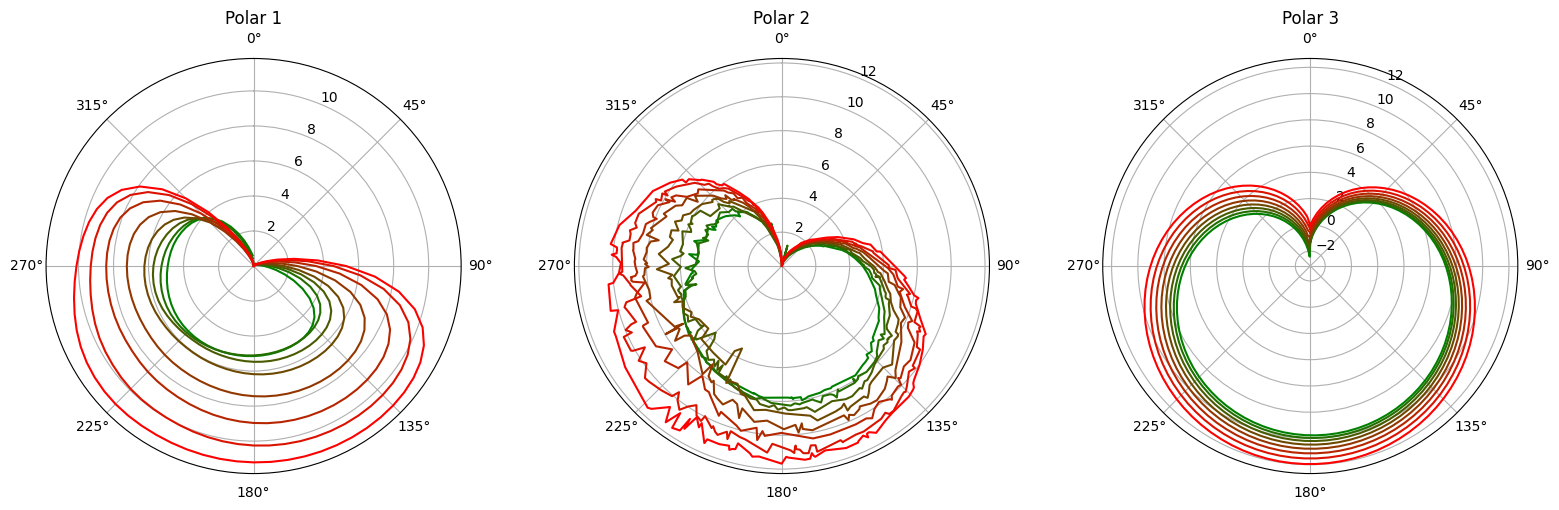

In [ ]:
ws = [4, 6, 8, 10, 12, 14, 16, 18] # m/s

plt.figure(figsize=(16, 5))

for i, pd in enumerate(pds):
    ax = plt.subplot(1, len(pds), i + 1, projection="hro polar")
    ax.plot(pd, ws=ws)
    ax.set_title(f"Polar {i+1}")

plt.tight_layout()
plt.show()
